# Predictions parquet EDA

This notebook inspects outputs from `pipelines.monthly.predict` (module `pipelines/monthly/predict.py`):

- `data/predictions/predictions_univariate_<YYYY-MM>.parquet` — one row per `(dimension, level_id)` at the eligible anchor month
- `data/predictions/predictions_fingerprint_<YYYY-MM>.parquet` — one row per 5-D fingerprint at the anchor

Schemas are defined in `pipelines/contracts.py` (`PREDICTIONS_*_COLUMNS`, `validate_predictions_*_frame`).

**If the directory is empty**, run the monthly predict step from the `trndly` package root (where `pipelines/` lives), e.g. `python -m pipelines.monthly.predict`, after merged cubes and trained models exist.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import display

import pandas as pd

# Locate package root (contains pipelines/paths.py), then import pipelines.
_here = Path.cwd().resolve()
_root = None
for candidate in [_here, *_here.parents]:
    if (candidate / "pipelines" / "paths.py").is_file():
        _root = candidate
        break
if _root is None:
    raise RuntimeError(
        "Cannot find pipelines/paths.py — run the notebook kernel with cwd inside the "
        "`trndly` repo tree (same folder level as `pipelines/`)."
    )
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from pipelines.contracts import (
    VALID_TREND_STATES,
    validate_predictions_fingerprint_frame,
    validate_predictions_univariate_frame,
)
from pipelines.paths import (
    PREDICTIONS_DIR,
    discover_predictions_fingerprint_parquets,
    discover_predictions_univariate_parquets,
    latest_predictions_fingerprint_parquet,
    latest_predictions_univariate_parquet,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

print("project_root:", _root)
print("predictions: ", PREDICTIONS_DIR)

project_root: /Users/jackcdawson/Desktop/trndly/trndly
predictions:  /Users/jackcdawson/Desktop/trndly/trndly/data/predictions


In [2]:
uv_paths = sorted(discover_predictions_univariate_parquets())
fp_paths = sorted(discover_predictions_fingerprint_parquets())

print(f"univariate files ({len(uv_paths)}):", [p.name for p in uv_paths])
print(f"fingerprint files ({len(fp_paths)}):", [p.name for p in fp_paths])

uv_path = latest_predictions_univariate_parquet()
fp_path = latest_predictions_fingerprint_parquet()
print("\nlatest univariate:", uv_path)
print("latest fingerprint:", fp_path)

df_uv = df_fp = None
if uv_path is not None:
    df_uv = validate_predictions_univariate_frame(pd.read_parquet(uv_path))
    print(f"\nloaded univariate: {uv_path.name} — {len(df_uv):,} rows")
if fp_path is not None:
    df_fp = validate_predictions_fingerprint_frame(pd.read_parquet(fp_path))
    print(f"loaded fingerprint: {fp_path.name} — {len(df_fp):,} rows")

if df_uv is None and df_fp is None:
    print(
        "\nNo parquet files under data/predictions/. "
        "Run `python -m pipelines.monthly.predict` from the project root after train/merge."
    )

univariate files (1): ['predictions_univariate_2020-08.parquet']
fingerprint files (1): ['predictions_fingerprint_2020-08.parquet']

latest univariate: /Users/jackcdawson/Desktop/trndly/trndly/data/predictions/predictions_univariate_2020-08.parquet
latest fingerprint: /Users/jackcdawson/Desktop/trndly/trndly/data/predictions/predictions_fingerprint_2020-08.parquet

loaded univariate: predictions_univariate_2020-08.parquet — 182 rows
loaded fingerprint: predictions_fingerprint_2020-08.parquet — 6,461 rows


In [5]:
HORIZONS = [f"y_h{h}" for h in range(1, 7)]

if df_uv is not None:
    print("anchor_month:", df_uv["anchor_month"].iloc[0] if len(df_uv) else None)
    print("model_version (sample):", df_uv["model_version"].drop_duplicates().head(3).tolist())
    display(df_uv.head(30))
    print("\n--- state ---")
    display(df_uv["state"].value_counts())
    print("\n--- rows per dimension ---")
    display(df_uv.groupby("dimension", observed=False).size().sort_values(ascending=False))
    print("\n--- horizons (share index) ---")
    display(df_uv[HORIZONS].describe(percentiles=[0.05, 0.5, 0.95]).T)
else:
    print("Skip: no univariate frame")

anchor_month: 2020-08-01 00:00:00
model_version (sample): ['2026-05-10T00:38:00+00:00']


,anchor_month,model_version,dimension,level_id,level_name,y_h1,y_h2,y_h3,y_h4,y_h5,y_h6,state,stat
0,2020-08-01,2026-05-10T00:38:00+00:00,product_type,1,Trousers,0.111,0.113,0.1151,0.1166,0.1181,0.1201,flat,stable
1,2020-08-01,2026-05-10T00:38:00+00:00,product_type,2,Dress,0.1284,0.1235,0.1215,0.1214,0.1224,0.1245,peak,at peak
2,2020-08-01,2026-05-10T00:38:00+00:00,product_type,3,Sweater,0.05797,0.05879,0.05884,0.05869,0.05796,0.05711,flat,stable
3,2020-08-01,2026-05-10T00:38:00+00:00,product_type,4,T-shirt,0.05312,0.05164,0.05035,0.04955,0.04908,0.04999,peak,at peak
4,2020-08-01,2026-05-10T00:38:00+00:00,product_type,5,Top,0.0469,0.04656,0.04667,0.04692,0.04782,0.04871,flat,stable
5,2020-08-01,2026-05-10T00:38:00+00:00,product_type,6,Blouse,0.04912,0.04804,0.04743,0.04746,0.04819,0.05035,peak,at peak
6,2020-08-01,2026-05-10T00:38:00+00:00,product_type,7,Vest top,0.03805,0.03674,0.0357,0.03558,0.03553,0.03538,peak,at peak
7,2020-08-01,2026-05-10T00:38:00+00:00,product_type,8,Bra,0.03058,0.03152,0.03268,0.0334,0.03378,0.03457,flat,stable
8,2020-08-01,2026-05-10T00:38:00+00:00,product_type,9,Bikini top,0.0219,0.02193,0.02186,0.02144,0.02174,0.02117,peak,at peak
9,2020-08-01,2026-05-10T00:38:00+00:00,product_type,10,Swimwear bottom,0.02226,0.02234,0.02217,0.02203,0.02203,0.02138,peak,at peak



--- state ---


state
flat       77
peak       57
rising     35
falling    13
Name: count, dtype: int64


--- rows per dimension ---


dimension
product_type            88
material                34
graphical_appearance    27
color_master            14
product_group            9
color_spectrum           7
gender                   3
dtype: int64


--- horizons (share index) ---


,count,mean,std,min,5%,50%,95%,max
y_h1,182,0.03815,0.08442,4.111e-05,0.0001689,0.007453,0.1676,0.6125
y_h2,182,0.03793,0.08438,4.184e-05,0.0001839,0.007385,0.166,0.6137
y_h3,182,0.03784,0.08444,4.265e-05,0.0001964,0.007487,0.1662,0.6159
y_h4,182,0.03787,0.08466,4.219e-05,0.0002221,0.007626,0.165,0.6207
y_h5,182,0.03795,0.08489,4.174e-05,0.0002278,0.007658,0.1643,0.6258
y_h6,182,0.03804,0.08507,4.141e-05,0.0002643,0.007508,0.1628,0.6299


In [6]:
if df_fp is not None:
    print("anchor_month:", df_fp["anchor_month"].iloc[0] if len(df_fp) else None)
    display(df_fp.head(10))
    print("\n--- state ---")
    display(df_fp["state"].value_counts())
    print("\n--- horizons ---")
    display(df_fp[HORIZONS].describe(percentiles=[0.05, 0.5, 0.95]).T)
    id_cols = [
        "product_type_id",
        "gender_id",
        "color_master_id",
        "graphical_appearance_id",
        "material_id",
    ]
    print("\n--- id dtypes ---")
    display(df_fp[id_cols].dtypes)
else:
    print("Skip: no fingerprint frame")

anchor_month: 2020-08-01 00:00:00


,anchor_month,model_version,product_type_id,gender_id,color_master_id,graphical_appearance_id,material_id,product_type_name,gender_name,color_master_name,graphical_appearance_name,material_name,y_h1,y_h2,y_h3,y_h4,y_h5,y_h6,state,stat
0,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,0,5,Trousers,Women,Unknown,Unknown,viscose,4.589e-05,4.962e-05,5.226e-05,5.267e-05,5.282e-05,5.302e-05,rising,+32% next 6mo
1,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,0,Trousers,Women,Unknown,Solid,Unknown,7.48e-05,9.817e-05,9.396e-05,9.863e-05,9.224e-05,8.626e-05,flat,stable
2,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,1,Trousers,Women,Unknown,Solid,cotton,7.812e-05,7.789e-05,7.789e-05,7.747e-05,7.59e-05,7.544e-05,peak,at peak
3,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,3,Trousers,Women,Unknown,Solid,denim,4.589e-05,4.962e-05,5.226e-05,5.267e-05,5.282e-05,5.302e-05,rising,+32% next 6mo
4,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,6,Trousers,Women,Unknown,Solid,knit,4.589e-05,4.962e-05,5.226e-05,5.267e-05,5.282e-05,5.302e-05,rising,+32% next 6mo
5,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,9,Trousers,Women,Unknown,Solid,wool,6.63e-05,7.723e-05,8.565e-05,8.415e-05,8.182e-05,7.829e-05,rising,+94% next 6mo
6,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,10,Trousers,Women,Unknown,Solid,twill,0.0001127,0.0001084,0.000103,9.87e-05,0.0001019,0.0001002,falling,−17% next 6mo
7,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,1,21,Trousers,Women,Unknown,Solid,lyocell,4.589e-05,4.962e-05,5.226e-05,5.267e-05,5.282e-05,5.302e-05,rising,+32% next 6mo
8,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,2,0,Trousers,Women,Unknown,All over pattern,Unknown,4.589e-05,4.962e-05,5.226e-05,5.267e-05,5.282e-05,5.302e-05,rising,+32% next 6mo
9,2020-08-01,2026-05-10T00:38:00+00:00,1,1,0,2,2,Trousers,Women,Unknown,All over pattern,jersey,4.659e-05,5.417e-05,5.759e-05,6.204e-05,5.769e-05,6.128e-05,rising,+52% next 6mo



--- state ---


state
rising     3692
peak       1118
flat       1032
falling     619
Name: count, dtype: int64


--- horizons ---


,count,mean,std,min,5%,50%,95%,max
y_h1,6461,0.0001447,0.0003069,4.589e-05,4.589e-05,7.749e-05,0.0004673,0.009008
y_h2,6461,0.000146,0.0003042,4.962e-05,4.962e-05,7.789e-05,0.0004506,0.008881
y_h3,6461,0.0001471,0.0003025,5.226e-05,5.226e-05,7.789e-05,0.0004462,0.008772
y_h4,6461,0.0001468,0.0003024,5.267e-05,5.267e-05,7.825e-05,0.0004407,0.008837
y_h5,6461,0.0001462,0.0003006,5.282e-05,5.282e-05,7.59e-05,0.0004427,0.008636
y_h6,6461,0.0001455,0.000295,5.302e-05,5.302e-05,7.544e-05,0.0004479,0.008257



--- id dtypes ---


product_type_id            int64
gender_id                  int64
color_master_id            int64
graphical_appearance_id    int64
material_id                int64
dtype: object

In [7]:
# Stack all months (if you have multiple prediction snapshots)
if uv_paths:
    multi_uv = pd.concat([pd.read_parquet(p) for p in uv_paths], ignore_index=True)
    multi_uv = validate_predictions_univariate_frame(multi_uv)
    print("univariate rows per anchor_month:")
    display(multi_uv.groupby("anchor_month").size().sort_index())
if fp_paths:
    multi_fp = pd.concat([pd.read_parquet(p) for p in fp_paths], ignore_index=True)
    multi_fp = validate_predictions_fingerprint_frame(multi_fp)
    print("\nfingerprint rows per anchor_month:")
    display(multi_fp.groupby("anchor_month").size().sort_index())
if not uv_paths and not fp_paths:
    print("No files to stack.")

univariate rows per anchor_month:


anchor_month
2020-08-01    182
dtype: int64


fingerprint rows per anchor_month:


anchor_month
2020-08-01    6461
dtype: int64

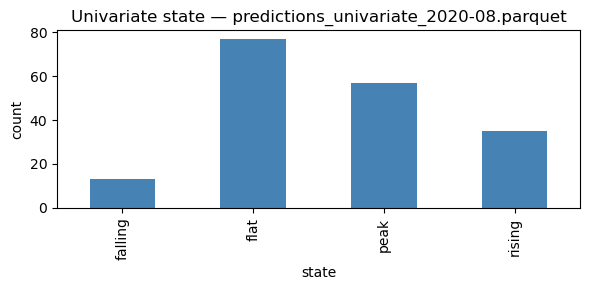

In [8]:
# Optional: bar chart of state mix (requires matplotlib)
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is not None and df_uv is not None and len(df_uv):
    fig, ax = plt.subplots(figsize=(6, 3))
    df_uv["state"].value_counts().reindex(sorted(VALID_TREND_STATES), fill_value=0).plot(
        kind="bar", ax=ax, color="steelblue"
    )
    ax.set_title(f"Univariate state — {uv_path.name}")
    ax.set_xlabel("state")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()
elif plt is None:
    print("matplotlib not installed; skip plot (pip install matplotlib)")
else:
    print("No univariate data to plot")